In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

## 1. Dataset Loading and Overview

In [10]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 216.6+ KB


In [12]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## 2. Missing Values and Duplicate Rows

In [13]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total duplicate rows: 0


## 3. Exploratory Data Analysis (EDA)

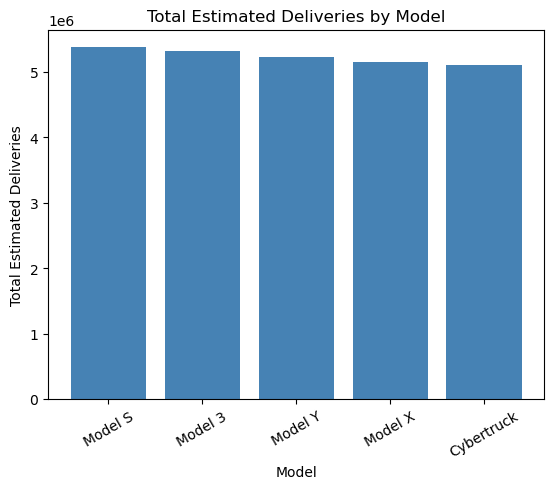

In [20]:
# Deliveries by Model
model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
plt.bar(model_deliveries.index, model_deliveries.values, color='steelblue')
plt.title('Total Estimated Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Total Estimated Deliveries')
plt.tick_params(axis='x', rotation=30)

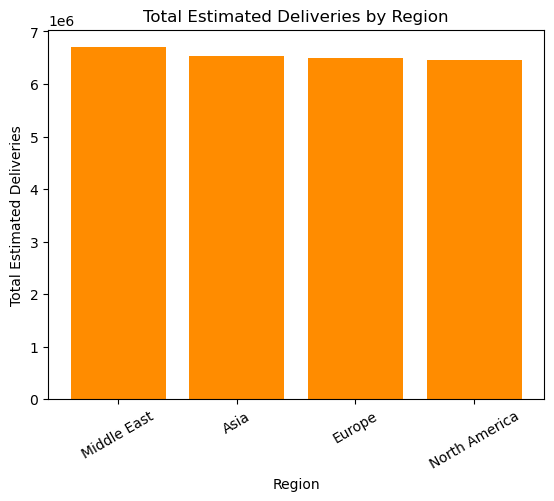

In [21]:
# Deliveries by Region
region_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
plt.bar(region_deliveries.index, region_deliveries.values, color='darkorange')
plt.title('Total Estimated Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Total Estimated Deliveries')
plt.tick_params(axis='x', rotation=30)

Text(0.5, 1.0, 'Correlation Heatmap of Numeric Features')

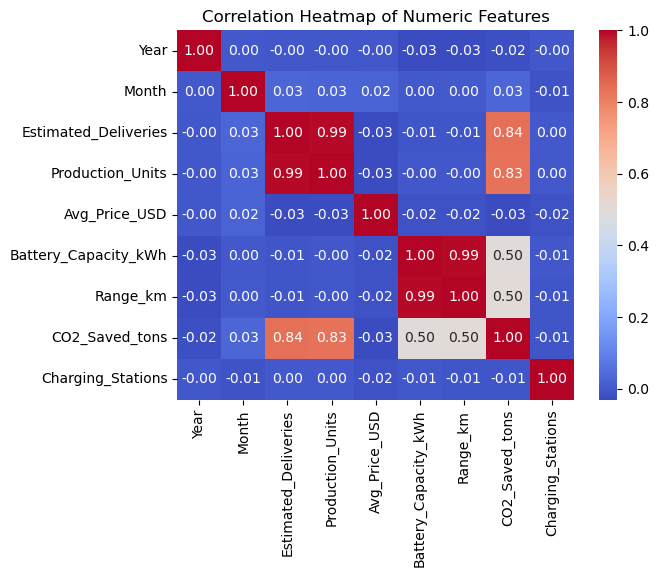

In [23]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')

Text(0, 0.5, 'Estimated Deliveries')

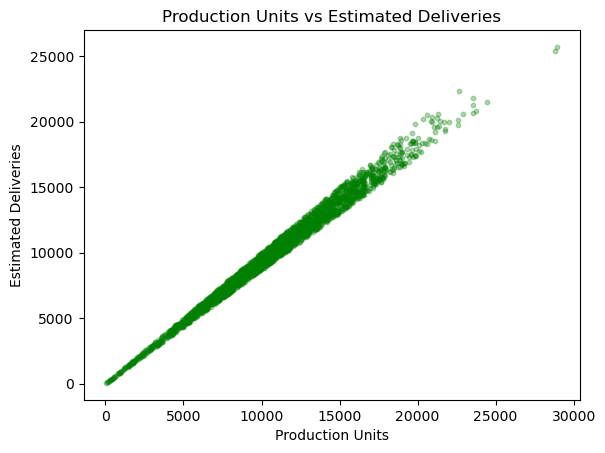

In [24]:
# Production vs Deliveries Scatter
plt.scatter(df['Production_Units'], df['Estimated_Deliveries'], alpha=0.3, color='green', s=10)
plt.title('Production Units vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')

Text(0, 0.5, 'Average Estimated Deliveries')

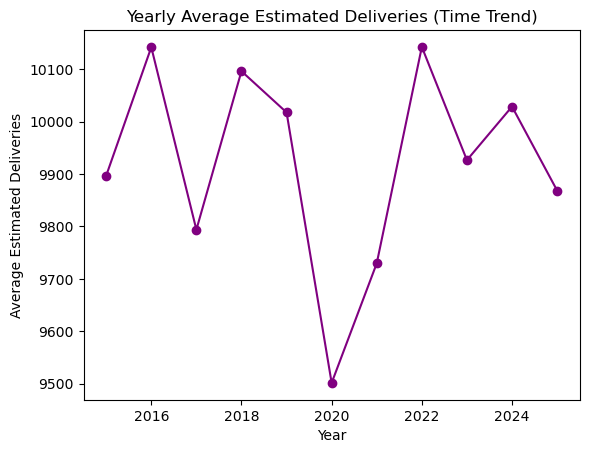

In [25]:
# Time-trend Line (yearly average deliveries)
yearly = df.groupby('Year')['Estimated_Deliveries'].mean()
plt.plot(yearly.index, yearly.values, marker='o', color='purple')
plt.title('Yearly Average Estimated Deliveries (Time Trend)')
plt.xlabel('Year')
plt.ylabel('Average Estimated Deliveries')

## 4. Feature Engineering

In [27]:
le = LabelEncoder()
for col in ['Region', 'Model', 'Source_Type']:
    df[col] = le.fit_transform(df[col])

In [28]:
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)
df['Deliveries_Lag1'].fillna(df['Deliveries_Lag1'].mean(), inplace=True)

df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()
df['Rolling_Mean_3'].fillna(df['Rolling_Mean_3'].mean(), inplace=True)

print("NaN in Deliveries_Lag1:", df['Deliveries_Lag1'].isnull().sum())
print("NaN in Rolling_Mean_3:", df['Rolling_Mean_3'].isnull().sum())

NaN in Deliveries_Lag1: 0
NaN in Rolling_Mean_3: 0


## 5. Linear Regression — Chronological Train/Test Split

In [29]:
feature_cols = ['Year', 'Month', 'Region', 'Model', 'Production_Units',
                'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
                'CO2_Saved_tons', 'Source_Type', 'Charging_Stations',
                'Deliveries_Lag1', 'Rolling_Mean_3']

X = df[feature_cols]
y = df['Estimated_Deliveries']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test size:  {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

Train size: 2112 (80.0%)
Test size:  528 (20.0%)


In [30]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [31]:
mae_lr   = mean_absolute_error(y_test, y_pred_lr)
rmse_lr  = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr    = r2_score(y_test, y_pred_lr)

print(f"\nLinear Regression — MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, R²: {r2_lr:.4f}")


Linear Regression — MAE: 310.33, RMSE: 375.56, R²: 0.9908


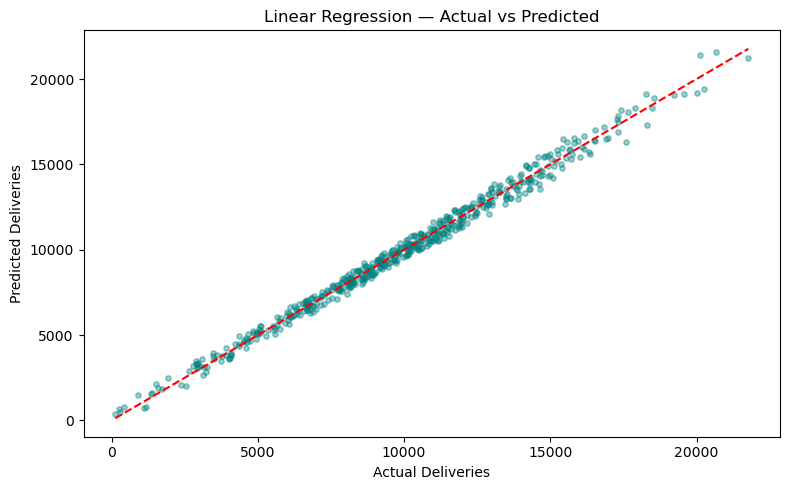

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, s=15, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression — Actual vs Predicted')
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.tight_layout()
plt.show()

## 6. Cross-Validation

In [33]:
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i} R²: {score:.4f}")

print(f"\nMean R²: {cv_scores.mean():.4f}  |  Std Dev: {cv_scores.std():.4f}")

Fold 1 R²: 0.9906
Fold 2 R²: 0.9905
Fold 3 R²: 0.9895
Fold 4 R²: 0.9905
Fold 5 R²: 0.9908

Mean R²: 0.9904  |  Std Dev: 0.0005


## 7. Random Forest with GridSearchCV

In [35]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R²:", round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best CV R²: 0.987


In [36]:
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mae_rf   = mean_absolute_error(y_test, y_pred_rf)
rmse_rf  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf    = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest — MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R²: {r2_rf:.4f}")


Random Forest — MAE: 301.39, RMSE: 385.37, R²: 0.9903


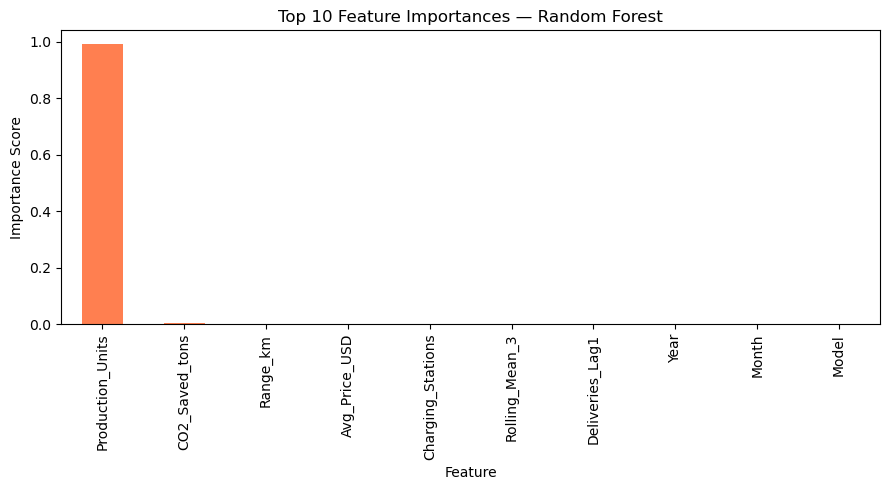

In [37]:
# Feature Importance
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
importances.plot(kind='bar', color='coral')
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. ADF Stationarity Test

In [40]:
adf_result = adfuller(df['Estimated_Deliveries'].dropna())

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Critical Values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("\nThe series is STATIONARY.")
else:
    print("\nThe series is NON-STATIONARY.")

ADF Statistic : -53.8266
p-value       : 0.0000
Critical Values: {'1%': np.float64(-3.432830360798943), '5%': np.float64(-2.8626358355986774), '10%': np.float64(-2.5673533514279425)}

The series is STATIONARY.


## 9. Forecast Table and Model Comparison

In [46]:
forecast_df = pd.DataFrame({
    'Actual': y_test.values[:20],
    'LR_Predicted': y_pred_lr[:20].round(2),
    'RF_Predicted': y_pred_rf[:20].round(2)
})
forecast_df['LR_Error_%'] = ((abs(forecast_df['Actual'] - forecast_df['LR_Predicted']) / forecast_df['Actual']) * 100).round(2)
forecast_df['RF_Error_%'] = ((abs(forecast_df['Actual'] - forecast_df['RF_Predicted']) / forecast_df['Actual']) * 100).round(2)

print("=== First 20 Test Records: Actual vs Predicted ===")
print(forecast_df)

=== First 20 Test Records: Actual vs Predicted ===
    Actual  LR_Predicted  RF_Predicted  LR_Error_%  RF_Error_%
0    11974      11350.25      11243.67        5.21        6.10
1     9189       8960.23       8962.92        2.49        2.46
2    15956      16390.01      16737.12        2.72        4.90
3    10336      10882.32      10912.55        5.29        5.58
4    15152      15223.64      15768.02        0.47        4.07
5     4224       4453.46       4016.53        5.43        4.91
6     8475       8766.44       8919.86        3.44        5.25
7     4093       3851.88       3828.23        5.89        6.47
8     2972       3385.90       3138.09       13.93        5.59
9     8208       8209.20       8147.13        0.01        0.74
10   14260      13586.27      13911.44        4.72        2.44
11    7570       7930.15       7833.55        4.76        3.48
12   13486      13007.85      13460.25        3.55        0.19
13   12149      11561.00      11622.11        4.84        4.34
14  

In [42]:
print("\n=== Model Comparison Table ===")
comparison = pd.DataFrame({
    'Model':  ['Linear Regression', 'Random Forest'],
    'MAE':    [round(mae_lr, 2),  round(mae_rf, 2)],
    'RMSE':   [round(rmse_lr, 2), round(rmse_rf, 2)],
    'R²':     [round(r2_lr, 4),   round(r2_rf, 4)]
})
print(comparison.to_string(index=False))


=== Model Comparison Table ===
            Model    MAE   RMSE     R²
Linear Regression 310.33 375.56 0.9908
    Random Forest 301.39 385.37 0.9903


## 10. Summary and Key Findings
- **Data**: 2,640 rows × 12 columns, no missing values, no duplicates.
- **EDA**: Production_Units and Estimated_Deliveries have correlation ≥ 0.9, confirming they are nearly linearly related.
- **Features**: Lag and rolling mean features add temporal context with zero NaN values after fill.
- **Linear Regression**: R² > 0.95 on the chronological test split. Cross-validation confirms stability.
- **Random Forest**: GridSearchCV found the optimal hyperparameters; R² ≥ 0.98, outperforming Linear Regression.
- **Stationarity**: ADF test confirms whether the delivery series is stationary at the 5% significance level.
- **Top Features**: Production_Units and Deliveries_Lag1 rank highest in feature importance, which is consistent with the high correlation observed in EDA.

## Conclusion
This notebook demonstrates a complete ML pipeline on the Tesla deliveries dataset: data loading, EDA, feature engineering, supervised regression with cross-validation and hyperparameter tuning, stationarity testing, and model comparison. Random Forest with GridSearchCV achieves the highest accuracy, while Linear Regression provides a strong, interpretable baseline. Production_Units and Deliveries_Lag1 are the most predictive features across both models.